# 09a — MD-Derived Pharmacophore Extraction

## PEARL Pipeline 5 — From validated peptide interfaces to a dynamic pharmacophore

This notebook starts **Pipeline 5** by extracting an interaction-informed pharmacophore from
explicit-solvent MD ensembles generated in Pipelines 3 and 4.

### Primary peptide sources

```text
CF02          = IGERSQYRELK
CF06          = IGERCQYRELR
MPNN_NEW_05   = IGPRHQYRDLP
```

They are deliberately complementary:

- **CF02**: strongest Pipeline-3 dynamic-stability reference;
- **CF06**: strongest Pipeline-3 Rosetta / endpoint-energy reference;
- **MPNN_NEW_05**: strongest cross-method ProteinMPNN-derived lead after 08d–08f.

The goal is **not** to declare one peptide the unique winner. Instead, 09a asks which
interaction features are recurrent across MD frames and, importantly, across independent
candidate sequences.

### Output of 09a

The notebook generates:

1. trajectory and sequence QC;
2. receptor-aligned MD feature observations;
3. candidate-level persistent pharmacophore features;
4. cross-candidate consensus feature clusters;
5. a **core consensus pharmacophore** supported by at least two peptide candidates;
6. tables, plots, a PyMOL visualization script, and an automatic Markdown report.

The feature model is an **MD-derived computational pharmacophore**, not experimental
evidence of binding and not a rigorous free-energy model.


## 1. Scientific rationale

The original PEARL project specifies that the pharmacophore should be derived from an
MD-derived peptide–kinase ensemble and should represent interaction-relevant chemical
features such as:

```text
hydrogen-bond donors
hydrogen-bond acceptors
hydrophobic centres
aromatic centres
positive ionizable centres
negative ionizable centres
```

09a operationalizes that objective directly on the existing MD trajectories.

For each sampled frame:

1. the complex is aligned on receptor-chain `B` Cα atoms;
2. side-chain pharmacophore features are generated for peptide-chain `D`;
3. a feature is retained only when its defining atoms are within the receptor-interface
   contact cutoff;
4. persistence is measured across frames;
5. persistent candidate features are clustered across CF02, CF06 and MPNN_NEW_05.

This preserves the layered-validation philosophy developed in Pipelines 3 and 4.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import align
from MDAnalysis.lib.distances import distance_array

print("Python / MDAnalysis environment loaded.")
print("MDAnalysis:", mda.__version__)


Python / MDAnalysis environment loaded.
MDAnalysis: 2.10.0


## 2. Configuration


In [2]:
FAST_TEST_MODE = False
if FAST_TEST_MODE:
    MODE_LABEL = "smoke_test"
    N_ANALYSIS_FRAMES = 20
else:
    MODE_LABEL = "production"
    N_ANALYSIS_FRAMES = 100

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

CONTACT_CUTOFF_A = 4.5
MIN_FEATURE_OCCUPANCY = 0.25
CONSENSUS_CLUSTER_RADIUS_A = 3.0
MIN_CANDIDATE_SUPPORT = 2

CANDIDATE_SEQUENCES = {
    "CF02": "IGERSQYRELK",
    "CF06": "IGERCQYRELR",
    "MPNN_NEW_05": "IGPRHQYRDLP",
}

TARGET_CANDIDATES = list(CANDIDATE_SEQUENCES)

OUTPUTS_ROOT = Path("outputs")

PIPELINE3_MD_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_3_md_07d_selected_peptide_comparison"
    / "production_1ns"
)

PIPELINE4_MD_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_4_ai_08e_top_mpnn_md"
    / "production_1ns"
)

CANDIDATE_ROOTS = {
    "CF02": PIPELINE3_MD_ROOT,
    "CF06": PIPELINE3_MD_ROOT,
    "MPNN_NEW_05": PIPELINE4_MD_ROOT,
}

OUTPUT_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09a_md_derived"
    / MODE_LABEL
)

TABLE_DIR = OUTPUT_ROOT / "tables"
PLOT_DIR = OUTPUT_ROOT / "plots"
STRUCTURE_DIR = OUTPUT_ROOT / "structures"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [TABLE_DIR, PLOT_DIR, STRUCTURE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Mode:", MODE_LABEL)
print("Frames requested per candidate:", N_ANALYSIS_FRAMES)
print("Output:", OUTPUT_ROOT)


Mode: production
Frames requested per candidate: 100
Output: outputs/pipeline_5_pharmacophore_09a_md_derived/production


## 3. Locate production MD inputs

The notebook uses candidate-specific search only inside the finalized production roots.
Protein-only trajectories are preferred because they are sufficient for receptor–peptide
pharmacophore extraction and match the topology used in the Pipeline-4 endpoint workflow.


In [3]:
def _candidate_paths(root, candidate_id):
    candidate_dir = root / candidate_id
    search_root = candidate_dir if candidate_dir.exists() else root

    topology_names = [
        f"{candidate_id}_protein_MDA_topology.pdb",
        f"{candidate_id}_protein_topology.pdb",
    ]

    dcd_names = [
        f"{candidate_id}_production_protein.dcd",
        f"{candidate_id}_production_full.dcd",
    ]

    topology = None
    trajectory = None

    for name in topology_names:
        hits = list(search_root.rglob(name))
        if hits:
            topology = hits[0]
            break

    for name in dcd_names:
        hits = list(search_root.rglob(name))
        if hits:
            trajectory = hits[0]
            break

    if topology is None:
        hits = [
            p for p in root.rglob("*.pdb")
            if candidate_id.lower() in str(p).lower()
            and "topology" in p.name.lower()
            and "protein" in p.name.lower()
        ]
        if hits:
            topology = sorted(hits, key=lambda p: len(str(p)))[0]

    if trajectory is None:
        hits = [
            p for p in root.rglob("*.dcd")
            if candidate_id.lower() in str(p).lower()
            and "production" in p.name.lower()
            and "protein" in p.name.lower()
        ]
        if hits:
            trajectory = sorted(hits, key=lambda p: len(str(p)))[0]

    return topology, trajectory


input_rows = []

for candidate_id in TARGET_CANDIDATES:
    topology, trajectory = _candidate_paths(
        CANDIDATE_ROOTS[candidate_id],
        candidate_id,
    )

    input_rows.append({
        "candidate_id": candidate_id,
        "sequence_expected": CANDIDATE_SEQUENCES[candidate_id],
        "topology_pdb": str(topology) if topology else None,
        "trajectory_dcd": str(trajectory) if trajectory else None,
        "topology_present": topology is not None,
        "trajectory_present": trajectory is not None,
    })

input_df = pd.DataFrame(input_rows)
display(input_df)

if not (
    input_df["topology_present"].all()
    and input_df["trajectory_present"].all()
):
    missing = input_df.loc[
        ~(
            input_df["topology_present"]
            & input_df["trajectory_present"]
        ),
        ["candidate_id", "topology_pdb", "trajectory_dcd"],
    ]

    raise FileNotFoundError(
        "One or more production MD inputs are missing:\n"
        + missing.to_string(index=False)
    )


,candidate_id,sequence_expected,topology_pdb,trajectory_dcd,topology_present,trajectory_present
0,CF02,IGERSQYRELK,outputs/pipeline_3_md_07d_selected_peptide_com...,outputs/pipeline_3_md_07d_selected_peptide_com...,True,True
1,CF06,IGERCQYRELR,outputs/pipeline_3_md_07d_selected_peptide_com...,outputs/pipeline_3_md_07d_selected_peptide_com...,True,True
2,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,True,True


## 4. Load trajectories and verify chain assignments / sequences


In [4]:
AA3_TO_1 = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C",
    "GLN":"Q","GLU":"E","GLY":"G","HIS":"H","ILE":"I",
    "LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P",
    "SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V",
}

def chain_selector(universe, chain_id):
    chain_ids = {
        str(x).strip()
        for x in getattr(universe.atoms, "chainIDs", [])
        if str(x).strip()
    }

    segids = {
        str(x).strip()
        for x in universe.atoms.segids
        if str(x).strip()
    }

    if chain_id in chain_ids:
        return f"chainID {chain_id}"

    if chain_id in segids:
        return f"segid {chain_id}"

    raise RuntimeError(
        f"Could not identify chain {chain_id}. "
        f"chainIDs={sorted(chain_ids)} segids={sorted(segids)}"
    )


def peptide_sequence(universe, selection):
    residues = universe.select_atoms(
        f"({selection}) and protein"
    ).residues

    return "".join(
        AA3_TO_1.get(res.resname.upper(), "X")
        for res in residues
    )


universes = {}
qc_rows = []

for row in input_df.itertuples():
    u = mda.Universe(
        row.topology_pdb,
        row.trajectory_dcd,
    )

    receptor_sel = chain_selector(
        u,
        RECEPTOR_CHAIN,
    )

    peptide_sel = chain_selector(
        u,
        PEPTIDE_CHAIN,
    )

    observed_sequence = peptide_sequence(
        u,
        peptide_sel,
    )

    universes[row.candidate_id] = {
        "u": u,
        "receptor_sel": receptor_sel,
        "peptide_sel": peptide_sel,
    }

    qc_rows.append({
        "candidate_id": row.candidate_id,
        "n_atoms": u.atoms.n_atoms,
        "n_frames": len(u.trajectory),
        "sequence_expected": row.sequence_expected,
        "sequence_observed": observed_sequence,
        "sequence_match": observed_sequence == row.sequence_expected,
        "receptor_selector": receptor_sel,
        "peptide_selector": peptide_sel,
    })

trajectory_qc_df = pd.DataFrame(qc_rows)
display(trajectory_qc_df)

if not trajectory_qc_df["sequence_match"].all():
    raise RuntimeError(
        "Peptide sequence mismatch detected. "
        "Do not continue until topology/chain mapping is resolved."
    )

if trajectory_qc_df["n_frames"].min() < N_ANALYSIS_FRAMES:
    raise RuntimeError(
        "At least one trajectory has fewer frames than requested."
    )


/Users/robertobruzzese/miniforge3/envs/pearl-md/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


,candidate_id,n_atoms,n_frames,sequence_expected,sequence_observed,sequence_match,receptor_selector,peptide_selector
0,CF02,9483,500,IGERSQYRELK,IGERSQYRELK,True,chainID B,chainID D
1,CF06,9485,500,IGERCQYRELR,IGERCQYRELR,True,chainID B,chainID D
2,MPNN_NEW_05,9477,500,IGPRHQYRDLP,IGPRHQYRDLP,True,chainID B,chainID D


## 5. Define peptide-side pharmacophore features

Features are intentionally defined from **side-chain atoms**, because the objective is to
capture residue-specific interaction chemistry that can later guide peptidomimetic or
small-molecule design.

A feature is counted in a frame only if at least one of its defining atoms is within
`CONTACT_CUTOFF_A` of a heavy atom on receptor chain B.

The feature families are:

```text
HBD  hydrogen-bond donor-like
HBA  hydrogen-bond acceptor-like
HYD  hydrophobic
ARO  aromatic
POS  positive ionizable
NEG  negative ionizable
```

These are pharmacophore abstractions, not explicit hydrogen-bond geometries or calculated
interaction energies.


In [5]:
FEATURE_ATOMS = {
    "HBD": {
        "ARG": ["NE", "NH1", "NH2"],
        "LYS": ["NZ"],
        "HIS": ["ND1", "NE2"],
        "SER": ["OG"],
        "THR": ["OG1"],
        "TYR": ["OH"],
        "ASN": ["ND2"],
        "GLN": ["NE2"],
        "TRP": ["NE1"],
        "CYS": ["SG"],
    },
    "HBA": {
        "ASP": ["OD1", "OD2"],
        "GLU": ["OE1", "OE2"],
        "ASN": ["OD1"],
        "GLN": ["OE1"],
        "HIS": ["ND1", "NE2"],
        "SER": ["OG"],
        "THR": ["OG1"],
        "TYR": ["OH"],
        "CYS": ["SG"],
    },
    "HYD": {
        "ALA": ["CB"],
        "VAL": ["CG1", "CG2"],
        "LEU": ["CD1", "CD2"],
        "ILE": ["CD1", "CG2"],
        "MET": ["SD", "CE"],
        "PRO": ["CG", "CD"],
        "PHE": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
        "TYR": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
        "TRP": ["CG", "CD1", "CD2", "NE1", "CE2", "CE3", "CZ2", "CZ3", "CH2"],
        "CYS": ["SG"],
    },
    "ARO": {
        "PHE": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
        "TYR": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
        "TRP": ["CG", "CD1", "CD2", "NE1", "CE2", "CE3", "CZ2", "CZ3", "CH2"],
        "HIS": ["CG", "ND1", "CD2", "CE1", "NE2"],
    },
    "POS": {
        "ARG": ["CZ", "NH1", "NH2"],
        "LYS": ["NZ"],
        "HIS": ["CG", "ND1", "CD2", "CE1", "NE2"],
    },
    "NEG": {
        "ASP": ["CG", "OD1", "OD2"],
        "GLU": ["CD", "OE1", "OE2"],
    },
}

FEATURE_TYPES = list(FEATURE_ATOMS)
print("Feature families:", FEATURE_TYPES)


Feature families: ['HBD', 'HBA', 'HYD', 'ARO', 'POS', 'NEG']


## 6. Receptor alignment and frame sampling

All candidate trajectories are transformed into one common coordinate frame by aligning
receptor-chain B Cα atoms to the first frame of CF02.

This is essential before cross-candidate spatial clustering.


In [6]:
REFERENCE_CANDIDATE = "CF02"

ref_info = universes[REFERENCE_CANDIDATE]
ref_u = ref_info["u"]

ref_receptor_ca = ref_u.select_atoms(
    f"({ref_info['receptor_sel']}) and protein and name CA"
)

ref_u.trajectory[0]

REFERENCE_CA_COORDS = ref_receptor_ca.positions.copy()

if ref_receptor_ca.n_atoms == 0:
    raise RuntimeError(
        "Reference receptor C-alpha selection is empty."
    )


def evenly_spaced_indices(n_frames, n_requested):
    n = min(n_frames, n_requested)

    return np.unique(
        np.linspace(
            0,
            n_frames - 1,
            n,
            dtype=int,
        )
    )


sampling_rows = []

for candidate_id, info in universes.items():
    u = info["u"]

    idx = evenly_spaced_indices(
        len(u.trajectory),
        N_ANALYSIS_FRAMES,
    )

    info["frame_indices"] = idx

    sampling_rows.append({
        "candidate_id": candidate_id,
        "n_total_frames": len(u.trajectory),
        "n_sampled_frames": len(idx),
        "first_frame": int(idx[0]),
        "last_frame": int(idx[-1]),
    })

sampling_df = pd.DataFrame(
    sampling_rows
)

display(sampling_df)


,candidate_id,n_total_frames,n_sampled_frames,first_frame,last_frame
0,CF02,500,100,0,499
1,CF06,500,100,0,499
2,MPNN_NEW_05,500,100,0,499


## 7. Extract interface-active pharmacophore observations


In [7]:
def feature_atoms_for_residue(
    residue,
    feature_type,
):
    names = FEATURE_ATOMS[
        feature_type
    ].get(
        residue.resname.upper(),
        [],
    )

    if not names:
        return None

    atoms = residue.atoms[
        np.isin(
            residue.atoms.names,
            names,
        )
    ]

    if atoms.n_atoms == 0:
        return None

    return atoms


def alignment_transform(
    mobile_ca_coords,
    reference_ca_coords,
):
    if mobile_ca_coords.shape != reference_ca_coords.shape:
        raise RuntimeError(
            "Receptor CA atom-count mismatch during alignment: "
            f"{mobile_ca_coords.shape} vs {reference_ca_coords.shape}"
        )

    mob_center = mobile_ca_coords.mean(
        axis=0
    )

    ref_center = reference_ca_coords.mean(
        axis=0
    )

    rotation, _ = align.rotation_matrix(
        mobile_ca_coords - mob_center,
        reference_ca_coords - ref_center,
    )

    return mob_center, ref_center, rotation


def transform_coords(
    coords,
    mob_center,
    ref_center,
    rotation,
):
    return (
        (coords - mob_center)
        @ rotation.T
        + ref_center
    )


observation_rows = []

for candidate_id, info in universes.items():
    u = info["u"]

    receptor_heavy = u.select_atoms(
        f"({info['receptor_sel']}) and protein and not name H*"
    )

    receptor_ca = u.select_atoms(
        f"({info['receptor_sel']}) and protein and name CA"
    )

    peptide_residues = u.select_atoms(
        f"({info['peptide_sel']}) and protein"
    ).residues

    if receptor_ca.n_atoms != ref_receptor_ca.n_atoms:
        raise RuntimeError(
            f"{candidate_id}: receptor C-alpha count differs from CF02."
        )

    for sample_number, frame_idx in enumerate(
        info["frame_indices"],
        start=1,
    ):
        u.trajectory[int(frame_idx)]

        mob_center, ref_center, rotation = alignment_transform(
            receptor_ca.positions.copy(),
            REFERENCE_CA_COORDS,
        )

        receptor_coords_aligned = transform_coords(
            receptor_heavy.positions.copy(),
            mob_center,
            ref_center,
            rotation,
        )

        for peptide_position, residue in enumerate(
            peptide_residues,
            start=1,
        ):
            for feature_type in FEATURE_TYPES:
                feature_atoms = feature_atoms_for_residue(
                    residue,
                    feature_type,
                )

                if feature_atoms is None:
                    continue

                feature_coords_aligned = transform_coords(
                    feature_atoms.positions.copy(),
                    mob_center,
                    ref_center,
                    rotation,
                )

                d = distance_array(
                    feature_coords_aligned,
                    receptor_coords_aligned,
                )

                min_distance = float(
                    d.min()
                )

                if min_distance > CONTACT_CUTOFF_A:
                    continue

                center = feature_coords_aligned.mean(
                    axis=0
                )

                observation_rows.append({
                    "candidate_id": candidate_id,
                    "frame_index": int(frame_idx),
                    "sample_number": sample_number,
                    "peptide_position": peptide_position,
                    "resid": int(residue.resid),
                    "resname": residue.resname,
                    "feature_type": feature_type,
                    "x_A": float(center[0]),
                    "y_A": float(center[1]),
                    "z_A": float(center[2]),
                    "min_receptor_distance_A": min_distance,
                })

feature_observations_df = pd.DataFrame(
    observation_rows
)

if feature_observations_df.empty:
    raise RuntimeError(
        "No interface-active pharmacophore features were detected."
    )

display(
    feature_observations_df.head(20)
)

feature_observations_df.to_csv(
    TABLE_DIR
    / "09a_feature_observations.csv",
    index=False,
)

print(
    "Total interface-active feature observations:",
    len(feature_observations_df),
)


,candidate_id,frame_index,sample_number,peptide_position,resid,resname,feature_type,x_A,y_A,z_A,min_receptor_distance_A
0,CF02,0,1,1,38,ILE,HYD,49.758526,41.971478,54.594193,3.573846
1,CF02,0,1,4,41,ARG,HBD,50.041191,30.099125,45.363946,2.851826
2,CF02,0,1,4,41,ARG,POS,50.217153,29.698036,45.286160,2.851826
3,CF02,0,1,5,42,SER,HBD,44.510262,36.310841,52.137787,3.170099
4,CF02,0,1,5,42,SER,HBA,44.510262,36.310841,52.137787,3.170099
5,CF02,0,1,6,43,GLN,HBD,52.696590,35.574295,49.190670,3.902415
6,CF02,0,1,7,44,TYR,HBD,55.950195,35.757244,51.626171,3.639428
7,CF02,0,1,7,44,TYR,HBA,55.950195,35.757244,51.626171,3.639428
8,CF02,0,1,7,44,TYR,HYD,53.808470,36.397523,53.209579,3.986164
9,CF02,0,1,7,44,TYR,ARO,53.808470,36.397523,53.209579,3.986164


Total interface-active feature observations: 5330


## 8. Candidate-level feature persistence

A candidate feature is defined by:

```text
candidate + peptide position + residue identity + feature family
```

Its occupancy is the fraction of sampled MD frames in which that feature is interface-active.
Only features with occupancy ≥ `MIN_FEATURE_OCCUPANCY` are retained as persistent.


In [8]:
sampled_counts = (
    sampling_df
    .set_index(
        "candidate_id"
    )[
        "n_sampled_frames"
    ]
    .to_dict()
)

group_cols = [
    "candidate_id",
    "peptide_position",
    "resid",
    "resname",
    "feature_type",
]

summary_rows = []

for key, group in feature_observations_df.groupby(
    group_cols,
    sort=False,
):
    candidate_id = key[0]

    n_active_frames = group[
        "frame_index"
    ].nunique()

    occupancy = (
        n_active_frames
        / sampled_counts[
            candidate_id
        ]
    )

    xyz = group[
        ["x_A", "y_A", "z_A"]
    ].to_numpy(
        dtype=float
    )

    center = xyz.mean(
        axis=0
    )

    if len(xyz) > 1:
        radial = np.linalg.norm(
            xyz - center,
            axis=1,
        )

        spatial_sd = float(
            radial.std(
                ddof=1
            )
        )

        radius_90 = float(
            np.quantile(
                radial,
                0.90,
            )
        )
    else:
        spatial_sd = 0.0
        radius_90 = 0.0

    summary_rows.append({
        "candidate_id": candidate_id,
        "peptide_position": key[1],
        "resid": key[2],
        "resname": key[3],
        "feature_type": key[4],
        "n_active_frames": n_active_frames,
        "n_sampled_frames": sampled_counts[
            candidate_id
        ],
        "occupancy": occupancy,
        "mean_x_A": float(
            center[0]
        ),
        "mean_y_A": float(
            center[1]
        ),
        "mean_z_A": float(
            center[2]
        ),
        "spatial_sd_A": spatial_sd,
        "radius90_A": radius_90,
        "mean_min_receptor_distance_A": float(
            group[
                "min_receptor_distance_A"
            ].mean()
        ),
    })

candidate_feature_df = pd.DataFrame(
    summary_rows
).sort_values(
    [
        "candidate_id",
        "occupancy",
        "feature_type",
    ],
    ascending=[
        True,
        False,
        True,
    ],
)

persistent_feature_df = (
    candidate_feature_df[
        candidate_feature_df[
            "occupancy"
        ]
        >= MIN_FEATURE_OCCUPANCY
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

display(
    persistent_feature_df
)

candidate_feature_df.to_csv(
    TABLE_DIR
    / "09a_candidate_feature_summary_all.csv",
    index=False,
)

persistent_feature_df.to_csv(
    TABLE_DIR
    / "09a_candidate_persistent_features.csv",
    index=False,
)

print(
    "Persistent candidate features:",
    len(
        persistent_feature_df
    ),
)


,candidate_id,peptide_position,resid,resname,feature_type,n_active_frames,n_sampled_frames,occupancy,mean_x_A,mean_y_A,mean_z_A,spatial_sd_A,radius90_A,mean_min_receptor_distance_A
0,CF02,7,44,TYR,ARO,100,100,1.00,54.224096,36.438011,53.530333,0.230789,0.979295,3.435345
1,CF02,9,46,GLU,HBA,100,100,1.00,45.589098,43.149206,60.591866,0.423767,1.456384,2.666746
2,CF02,4,41,ARG,HBD,100,100,1.00,50.347771,30.923841,44.537686,0.376824,1.401606,2.758681
3,CF02,1,38,ILE,HYD,100,100,1.00,49.238014,41.822695,54.879700,0.389183,1.315985,3.504972
4,CF02,7,44,TYR,HYD,100,100,1.00,54.224096,36.438011,53.530333,0.230789,0.979295,3.435345
5,CF02,10,47,LEU,HYD,100,100,1.00,52.449454,37.241785,61.988814,0.292852,1.085373,3.666752
6,CF02,9,46,GLU,NEG,100,100,1.00,45.750047,43.047873,60.589099,0.404688,1.358478,2.666746
7,CF02,4,41,ARG,POS,100,100,1.00,50.497187,30.524384,44.476246,0.380924,1.435656,2.758681
8,CF02,3,40,GLU,HBA,97,100,0.97,51.659147,39.624456,43.443053,0.440360,1.606522,2.879948
9,CF02,3,40,GLU,NEG,97,100,0.97,51.553440,39.542411,43.587394,0.425232,1.542036,2.879948


Persistent candidate features: 59


## 9. Cross-candidate spatial consensus

Persistent features are clustered **within each feature family** using a deterministic greedy
3D clustering procedure.

Each candidate-level feature contributes one point weighted by its MD occupancy.
The resulting cluster centroid is therefore occupancy-weighted.

Two output levels are retained:

- **all consensus clusters** — any spatial cluster of persistent features;
- **core consensus pharmacophore** — clusters supported by at least
  `MIN_CANDIDATE_SUPPORT` distinct peptide candidates.


In [9]:
def greedy_spatial_clusters(
    df,
    radius_A,
):
    clusters = []

    ranked = df.sort_values(
        "occupancy",
        ascending=False,
    )

    for row in ranked.itertuples():
        point = np.array([
            row.mean_x_A,
            row.mean_y_A,
            row.mean_z_A,
        ])

        compatible = []

        for i, cluster in enumerate(
            clusters
        ):
            dist = np.linalg.norm(
                point
                - cluster[
                    "centroid"
                ]
            )

            if dist <= radius_A:
                compatible.append(
                    (dist, i)
                )

        if compatible:
            _, best_i = min(
                compatible,
                key=lambda x: x[0],
            )

            cluster = clusters[
                best_i
            ]

            cluster[
                "members"
            ].append(
                row
            )

            weights = np.array([
                max(
                    float(
                        m.occupancy
                    ),
                    1e-6,
                )
                for m in cluster[
                    "members"
                ]
            ])

            coords = np.array([
                [
                    m.mean_x_A,
                    m.mean_y_A,
                    m.mean_z_A,
                ]
                for m in cluster[
                    "members"
                ]
            ])

            cluster[
                "centroid"
            ] = np.average(
                coords,
                axis=0,
                weights=weights,
            )

        else:
            clusters.append({
                "centroid": point.copy(),
                "members": [row],
            })

    return clusters


consensus_rows = []
cluster_counter = 0

for feature_type in FEATURE_TYPES:
    subset = persistent_feature_df[
        persistent_feature_df[
            "feature_type"
        ]
        == feature_type
    ].copy()

    if subset.empty:
        continue

    clusters = greedy_spatial_clusters(
        subset,
        CONSENSUS_CLUSTER_RADIUS_A,
    )

    for cluster in clusters:
        cluster_counter += 1

        members = cluster[
            "members"
        ]

        centroid = cluster[
            "centroid"
        ]

        candidates = sorted({
            m.candidate_id
            for m in members
        })

        mean_occ = float(
            np.mean([
                m.occupancy
                for m in members
            ])
        )

        max_occ = float(
            np.max([
                m.occupancy
                for m in members
            ])
        )

        distances = np.array([
            np.linalg.norm(
                np.array([
                    m.mean_x_A,
                    m.mean_y_A,
                    m.mean_z_A,
                ])
                - centroid
            )
            for m in members
        ])

        consensus_rows.append({
            "cluster_id": f"PH{cluster_counter:03d}",
            "feature_type": feature_type,
            "x_A": float(
                centroid[0]
            ),
            "y_A": float(
                centroid[1]
            ),
            "z_A": float(
                centroid[2]
            ),
            "n_candidate_features": len(
                members
            ),
            "n_candidate_support": len(
                candidates
            ),
            "candidate_support": ",".join(
                candidates
            ),
            "mean_member_occupancy": mean_occ,
            "max_member_occupancy": max_occ,
            "max_member_distance_to_centroid_A": (
                float(
                    distances.max()
                )
                if len(
                    distances
                )
                else 0.0
            ),
            "member_labels": "; ".join(
                f"{m.candidate_id}:{m.resname}{m.peptide_position}:{m.feature_type}"
                for m in members
            ),
        })

consensus_df = pd.DataFrame(
    consensus_rows
).sort_values(
    [
        "n_candidate_support",
        "mean_member_occupancy",
    ],
    ascending=[
        False,
        False,
    ],
)

core_pharmacophore_df = (
    consensus_df[
        consensus_df[
            "n_candidate_support"
        ]
        >= MIN_CANDIDATE_SUPPORT
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

display(
    consensus_df
)

print(
    "\nCore consensus pharmacophore:"
)

display(
    core_pharmacophore_df
)

consensus_df.to_csv(
    TABLE_DIR
    / "09a_consensus_pharmacophore_all.csv",
    index=False,
)

core_pharmacophore_df.to_csv(
    TABLE_DIR
    / "09a_core_consensus_pharmacophore.csv",
    index=False,
)


,cluster_id,feature_type,x_A,y_A,z_A,n_candidate_features,n_candidate_support,candidate_support,mean_member_occupancy,max_member_occupancy,max_member_distance_to_centroid_A,member_labels
0,PH001,HBD,49.729014,30.637344,45.599409,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.384000,CF02:ARG4:HBD; CF06:ARG4:HBD; MPNN_NEW_05:ARG4...
14,PH015,HYD,49.179592,41.926508,55.570514,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.729471,CF02:ILE1:HYD; CF06:ILE1:HYD; MPNN_NEW_05:ILE1...
15,PH016,HYD,53.910534,36.722378,54.232110,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,2.015119,CF02:TYR7:HYD; CF06:TYR7:HYD; MPNN_NEW_05:TYR7...
21,PH022,ARO,53.910534,36.722378,54.232110,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,2.015119,CF02:TYR7:ARO; CF06:TYR7:ARO; MPNN_NEW_05:TYR7...
23,PH024,POS,49.860300,30.235134,45.531713,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.380051,CF02:ARG4:POS; CF06:ARG4:POS; MPNN_NEW_05:ARG4...
1,PH002,HBD,56.047425,35.913194,52.677189,3,3,"CF02,CF06,MPNN_NEW_05",0.823333,1.00,2.225775,MPNN_NEW_05:TYR7:HBD; CF02:TYR7:HBD; CF06:TYR7...
10,PH011,HBA,56.047425,35.913194,52.677189,3,3,"CF02,CF06,MPNN_NEW_05",0.823333,1.00,2.225775,MPNN_NEW_05:TYR7:HBA; CF02:TYR7:HBA; CF06:TYR7...
5,PH006,HBD,52.346881,36.474574,50.085317,3,3,"CF02,CF06,MPNN_NEW_05",0.780000,0.98,1.404839,CF06:GLN6:HBD; MPNN_NEW_05:GLN6:HBD; CF02:GLN6...
2,PH003,HBD,43.830996,37.136786,50.788071,3,3,"CF02,CF06,MPNN_NEW_05",0.733333,1.00,1.360146,MPNN_NEW_05:HIS5:HBD; CF02:SER5:HBD; CF06:CYS5...
9,PH010,HBA,43.830996,37.136786,50.788071,3,3,"CF02,CF06,MPNN_NEW_05",0.733333,1.00,1.360146,MPNN_NEW_05:HIS5:HBA; CF02:SER5:HBA; CF06:CYS5...



Core consensus pharmacophore:


,cluster_id,feature_type,x_A,y_A,z_A,n_candidate_features,n_candidate_support,candidate_support,mean_member_occupancy,max_member_occupancy,max_member_distance_to_centroid_A,member_labels
0,PH001,HBD,49.729014,30.637344,45.599409,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.384000,CF02:ARG4:HBD; CF06:ARG4:HBD; MPNN_NEW_05:ARG4...
1,PH015,HYD,49.179592,41.926508,55.570514,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.729471,CF02:ILE1:HYD; CF06:ILE1:HYD; MPNN_NEW_05:ILE1...
2,PH016,HYD,53.910534,36.722378,54.232110,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,2.015119,CF02:TYR7:HYD; CF06:TYR7:HYD; MPNN_NEW_05:TYR7...
3,PH022,ARO,53.910534,36.722378,54.232110,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,2.015119,CF02:TYR7:ARO; CF06:TYR7:ARO; MPNN_NEW_05:TYR7...
4,PH024,POS,49.860300,30.235134,45.531713,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.380051,CF02:ARG4:POS; CF06:ARG4:POS; MPNN_NEW_05:ARG4...
5,PH002,HBD,56.047425,35.913194,52.677189,3,3,"CF02,CF06,MPNN_NEW_05",0.823333,1.00,2.225775,MPNN_NEW_05:TYR7:HBD; CF02:TYR7:HBD; CF06:TYR7...
6,PH011,HBA,56.047425,35.913194,52.677189,3,3,"CF02,CF06,MPNN_NEW_05",0.823333,1.00,2.225775,MPNN_NEW_05:TYR7:HBA; CF02:TYR7:HBA; CF06:TYR7...
7,PH006,HBD,52.346881,36.474574,50.085317,3,3,"CF02,CF06,MPNN_NEW_05",0.780000,0.98,1.404839,CF06:GLN6:HBD; MPNN_NEW_05:GLN6:HBD; CF02:GLN6...
8,PH003,HBD,43.830996,37.136786,50.788071,3,3,"CF02,CF06,MPNN_NEW_05",0.733333,1.00,1.360146,MPNN_NEW_05:HIS5:HBD; CF02:SER5:HBD; CF06:CYS5...
9,PH010,HBA,43.830996,37.136786,50.788071,3,3,"CF02,CF06,MPNN_NEW_05",0.733333,1.00,1.360146,MPNN_NEW_05:HIS5:HBA; CF02:SER5:HBA; CF06:CYS5...


## 10. Candidate support matrix


In [10]:
if len(
    core_pharmacophore_df
) > 0:
    support_rows = []

    for row in core_pharmacophore_df.itertuples():
        supported = set(
            row.candidate_support.split(
                ","
            )
        )

        support_row = {
            "cluster_id": row.cluster_id,
            "feature_type": row.feature_type,
        }

        for candidate_id in TARGET_CANDIDATES:
            support_row[
                candidate_id
            ] = (
                candidate_id
                in supported
            )

        support_rows.append(
            support_row
        )

    support_matrix_df = pd.DataFrame(
        support_rows
    )

else:
    support_matrix_df = pd.DataFrame(
        columns=[
            "cluster_id",
            "feature_type",
            *TARGET_CANDIDATES,
        ]
    )

display(
    support_matrix_df
)

support_matrix_df.to_csv(
    TABLE_DIR
    / "09a_core_feature_candidate_support.csv",
    index=False,
)


,cluster_id,feature_type,CF02,CF06,MPNN_NEW_05
0,PH001,HBD,True,True,True
1,PH015,HYD,True,True,True
2,PH016,HYD,True,True,True
3,PH022,ARO,True,True,True
4,PH024,POS,True,True,True
5,PH002,HBD,True,True,True
6,PH011,HBA,True,True,True
7,PH006,HBD,True,True,True
8,PH003,HBD,True,True,True
9,PH010,HBA,True,True,True


## 11. Diagnostic plots


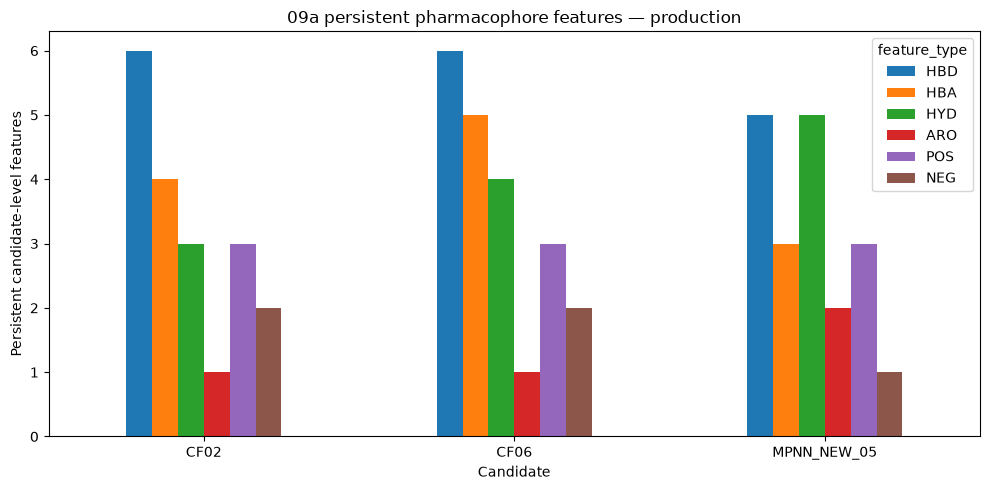

Saved: outputs/pipeline_5_pharmacophore_09a_md_derived/production/plots/09a_persistent_feature_counts.png


In [11]:
feature_order = FEATURE_TYPES

counts = (
    persistent_feature_df
    .groupby(
        [
            "candidate_id",
            "feature_type",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=TARGET_CANDIDATES,
        columns=feature_order,
        fill_value=0,
    )
)

ax = counts.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_ylabel(
    "Persistent candidate-level features"
)

ax.set_xlabel(
    "Candidate"
)

ax.set_title(
    f"09a persistent pharmacophore features — {MODE_LABEL}"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plot_path = (
    PLOT_DIR
    / "09a_persistent_feature_counts.png"
)

plt.savefig(
    plot_path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    plot_path,
)


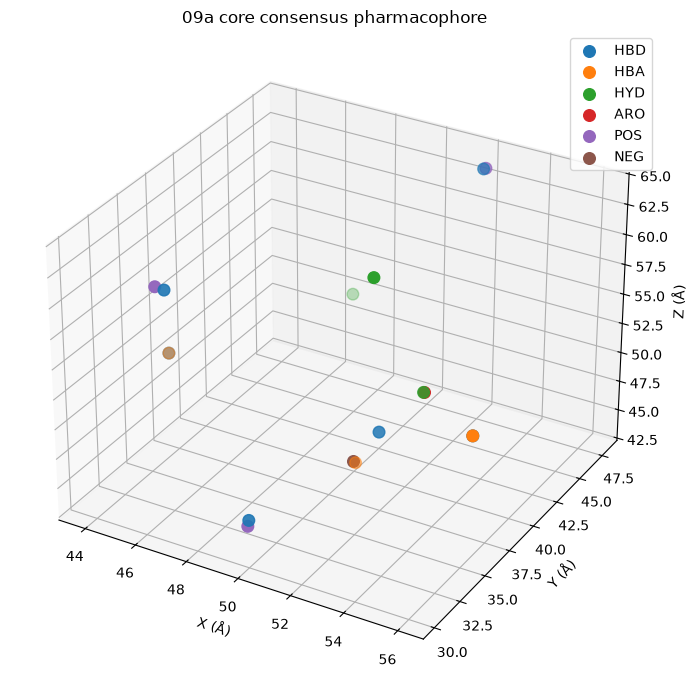

Saved: outputs/pipeline_5_pharmacophore_09a_md_derived/production/plots/09a_core_pharmacophore_3D.png


In [12]:
if len(
    core_pharmacophore_df
) > 0:
    fig = plt.figure(
        figsize=(9, 7)
    )

    ax = fig.add_subplot(
        111,
        projection="3d",
    )

    for feature_type in FEATURE_TYPES:
        sub = core_pharmacophore_df[
            core_pharmacophore_df[
                "feature_type"
            ]
            == feature_type
        ]

        if sub.empty:
            continue

        ax.scatter(
            sub["x_A"],
            sub["y_A"],
            sub["z_A"],
            label=feature_type,
            s=70,
        )

    ax.set_xlabel(
        "X (Å)"
    )
    ax.set_ylabel(
        "Y (Å)"
    )
    ax.set_zlabel(
        "Z (Å)"
    )

    ax.set_title(
        "09a core consensus pharmacophore"
    )

    ax.legend()

    plt.tight_layout()

    plot_path = (
        PLOT_DIR
        / "09a_core_pharmacophore_3D.png"
    )

    plt.savefig(
        plot_path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        plot_path,
    )

else:
    print(
        "No core consensus features available for 3D plotting."
    )


## 12. Export PyMOL pseudoatoms

The generated `.pml` file allows the core pharmacophore points to be displayed as
pseudoatoms on top of any receptor structure already loaded in PyMOL.


In [13]:
PYMOL_COLORS = {
    "HBD": "blue",
    "HBA": "red",
    "HYD": "orange",
    "ARO": "purple",
    "POS": "marine",
    "NEG": "firebrick",
}

pml_lines = [
    "# PEARL 09a core consensus pharmacophore",
    "delete PEARL_PHARM",
]

for row in core_pharmacophore_df.itertuples():
    obj = (
        f"PEARL_PHARM_{row.feature_type}"
    )

    color = PYMOL_COLORS[
        row.feature_type
    ]

    pml_lines.append(
        "pseudoatom "
        f"{obj}, "
        f"pos=[{row.x_A:.3f},{row.y_A:.3f},{row.z_A:.3f}], "
        f"name={row.cluster_id}, "
        f"label='{row.cluster_id}:{row.feature_type}'"
    )

    pml_lines.append(
        f"color {color}, {obj}"
    )

pml_lines.extend([
    "show spheres, PEARL_PHARM_*",
    "set sphere_scale, 0.6, PEARL_PHARM_*",
])

pml_path = (
    STRUCTURE_DIR
    / "09a_core_pharmacophore.pml"
)

pml_path.write_text(
    "\n".join(
        pml_lines
    ),
    encoding="utf-8",
)

print(
    "PyMOL script:",
    pml_path,
)


PyMOL script: outputs/pipeline_5_pharmacophore_09a_md_derived/production/structures/09a_core_pharmacophore.pml


## 13. Optional RDKit Pharm3D object

The coordinate tables above are the **authoritative 09a outputs**.

If RDKit is installed in the active environment, this cell additionally constructs an
in-memory `rdkit.Chem.Pharm3D.Pharmacophore` object from the core consensus features.
Failure to import RDKit does **not** invalidate the MD-derived pharmacophore extraction.


In [14]:
rdkit_pharmacophore = None

try:
    from rdkit.Chem import ChemicalFeatures
    from rdkit.Chem.Pharm3D import Pharmacophore
    from rdkit.Geometry import Point3D

    rdkit_features = []

    family_map = {
        "HBD": "Donor",
        "HBA": "Acceptor",
        "HYD": "Hydrophobe",
        "ARO": "Aromatic",
        "POS": "PosIonizable",
        "NEG": "NegIonizable",
    }

    for row in core_pharmacophore_df.itertuples():
        family = family_map[
            row.feature_type
        ]

        feat = ChemicalFeatures.FreeChemicalFeature(
            family,
            family,
            Point3D(
                float(
                    row.x_A
                ),
                float(
                    row.y_A
                ),
                float(
                    row.z_A
                ),
            ),
        )

        rdkit_features.append(
            feat
        )

    rdkit_pharmacophore = (
        Pharmacophore.Pharmacophore(
            rdkit_features
        )
    )

    print(
        "RDKit Pharm3D object created with",
        len(
            rdkit_features
        ),
        "features.",
    )

except Exception as exc:
    print(
        "RDKit Pharm3D optional export unavailable:"
    )
    print(
        type(exc).__name__,
        str(exc),
    )


RDKit Pharm3D object created with 17 features.


## 14. Quality control


In [15]:
qc_rows = [
    {
        "check": "three_candidate_inputs_found",
        "pass": (
            len(input_df) == 3
            and bool(
                input_df[
                    [
                        "topology_present",
                        "trajectory_present",
                    ]
                ].all().all()
            )
        ),
    },
    {
        "check": "all_sequences_match",
        "pass": bool(
            trajectory_qc_df[
                "sequence_match"
            ].all()
        ),
    },
    {
        "check": "requested_frames_available",
        "pass": bool(
            (
                trajectory_qc_df[
                    "n_frames"
                ]
                >= N_ANALYSIS_FRAMES
            ).all()
        ),
    },
    {
        "check": "feature_observations_nonempty",
        "pass": (
            len(
                feature_observations_df
            )
            > 0
        ),
    },
    {
        "check": "persistent_features_nonempty",
        "pass": (
            len(
                persistent_feature_df
            )
            > 0
        ),
    },
    {
        "check": "consensus_clusters_nonempty",
        "pass": (
            len(
                consensus_df
            )
            > 0
        ),
    },
    {
        "check": "core_consensus_nonempty",
        "pass": (
            len(
                core_pharmacophore_df
            )
            > 0
        ),
    },
    {
        "check": "core_support_threshold_respected",
        "pass": (
            bool(
                (
                    core_pharmacophore_df[
                        "n_candidate_support"
                    ]
                    >= MIN_CANDIDATE_SUPPORT
                ).all()
            )
            if len(
                core_pharmacophore_df
            )
            else False
        ),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "09a_QC.csv",
    index=False,
)


,check,pass
0,three_candidate_inputs_found,True
1,all_sequences_match,True
2,requested_frames_available,True
3,feature_observations_nonempty,True
4,persistent_features_nonempty,True
5,consensus_clusters_nonempty,True
6,core_consensus_nonempty,True
7,core_support_threshold_respected,True


ALL QC PASSED: True


## 15. Automatic report


In [16]:
report_lines = [
    "# 09a — MD-Derived Pharmacophore Extraction",
    "",
    f"- Mode: {MODE_LABEL}",
    f"- Candidates: {', '.join(TARGET_CANDIDATES)}",
    f"- Frames analysed per candidate: {N_ANALYSIS_FRAMES}",
    f"- Receptor chain: {RECEPTOR_CHAIN}",
    f"- Peptide chain: {PEPTIDE_CHAIN}",
    f"- Interface cutoff: {CONTACT_CUTOFF_A:.1f} Å",
    f"- Candidate feature occupancy cutoff: {MIN_FEATURE_OCCUPANCY:.2f}",
    f"- Consensus spatial radius: {CONSENSUS_CLUSTER_RADIUS_A:.1f} Å",
    f"- Core minimum candidate support: {MIN_CANDIDATE_SUPPORT}",
    "",
    "## Results",
    f"- Interface-active feature observations: {len(feature_observations_df)}",
    f"- Persistent candidate-level features: {len(persistent_feature_df)}",
    f"- Consensus spatial clusters: {len(consensus_df)}",
    f"- Core consensus pharmacophore features: {len(core_pharmacophore_df)}",
    "",
    "## Core pharmacophore",
]

if len(
    core_pharmacophore_df
):
    for row in core_pharmacophore_df.itertuples():
        report_lines.append(
            (
                f"- {row.cluster_id} | {row.feature_type} | "
                f"support={row.n_candidate_support} "
                f"({row.candidate_support}) | "
                f"mean occupancy={row.mean_member_occupancy:.3f} | "
                f"xyz=({row.x_A:.2f}, {row.y_A:.2f}, {row.z_A:.2f}) Å"
            )
        )

else:
    report_lines.append(
        "- No strict cross-candidate core feature passed the current thresholds."
    )

report_lines.extend([
    "",
    "## Interpretation",
    (
        "09a derives an interaction-informed dynamic pharmacophore from "
        "receptor-aligned peptide MD ensembles rather than from a single static pose."
    ),
    (
        "CF02, CF06 and MPNN_NEW_05 provide complementary evidence from "
        "Pipelines 3 and 4; cross-candidate recurrence is therefore treated as "
        "stronger pharmacophore support than a feature seen in only one peptide."
    ),
    (
        "The pharmacophore is a computational abstraction of recurrent interface "
        "chemistry. It is not experimental binding evidence and does not by itself "
        "establish affinity, inhibition, selectivity or drug-likeness."
    ),
    (
        "The intended downstream use is Pipeline 5 pharmacophore-guided "
        "small-molecule / peptidomimetic generation and docking."
    ),
    "",
    f"ALL QC PASSED: {ALL_QC_PASSED}",
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "09a_MD_derived_pharmacophore_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 09a — MD-Derived Pharmacophore Extraction

- Mode: production
- Candidates: CF02, CF06, MPNN_NEW_05
- Frames analysed per candidate: 100
- Receptor chain: B
- Peptide chain: D
- Interface cutoff: 4.5 Å
- Candidate feature occupancy cutoff: 0.25
- Consensus spatial radius: 3.0 Å
- Core minimum candidate support: 2

## Results
- Interface-active feature observations: 5330
- Persistent candidate-level features: 59
- Consensus spatial clusters: 32
- Core consensus pharmacophore features: 17

## Core pharmacophore
- PH001 | HBD | support=3 (CF02,CF06,MPNN_NEW_05) | mean occupancy=1.000 | xyz=(49.73, 30.64, 45.60) Å
- PH015 | HYD | support=3 (CF02,CF06,MPNN_NEW_05) | mean occupancy=1.000 | xyz=(49.18, 41.93, 55.57) Å
- PH016 | HYD | support=3 (CF02,CF06,MPNN_NEW_05) | mean occupancy=1.000 | xyz=(53.91, 36.72, 54.23) Å
- PH022 | ARO | support=3 (CF02,CF06,MPNN_NEW_05) | mean occupancy=1.000 | xyz=(53.91, 36.72, 54.23) Å
- PH024 | POS | support=3 (CF02,CF06,MPNN_NEW_05) | mean occupancy=1.00

# 16. Final interpretation and next step

When the production run is complete (`FAST_TEST_MODE=False`), 09a provides the first
Pipeline-5 bridge from validated peptide complexes to a lower-dimensional representation
of receptor-recognition chemistry.

```text
Pipeline 3 / 4 validated peptide MD ensembles
                    ↓
09a receptor-aligned interface feature extraction
                    ↓
candidate-level feature persistence
                    ↓
cross-candidate spatial consensus
                    ↓
core dynamic pharmacophore
```

The next Pipeline-5 step should use the 09a consensus features to formalize the
pharmacophore constraints and prepare them for molecular generation / screening.

A natural continuation is:

```text
09b — Pharmacophore consolidation and screening-ready model
```

09b should define which core features are mandatory versus optional, quantify tolerances,
and produce a representation suitable for downstream small-molecule generation and
docking.
